# Análise - Tabela Sumarizada de Clientes

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configurações de exibição
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.1f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [146]:
# Leitura dos dados
df = pd.read_csv('tabela_sumarizada_clientes.csv')

# Primeiras 10 linhas com inteiros formatados (separador de milhar)
int_cols = df.select_dtypes(include='integer').columns.tolist()
display(
    df.head(10)
    .style.format({c: '{:,.0f}' for c in int_cols})
    .set_caption('Primeiras 10 linhas')
)

# Dimensões do dataset
print(f'\nLinhas: {df.shape[0]:,}  |  Colunas: {df.shape[1]}')

# Tipos das variáveis
print('\nTipos das variáveis:')
for col in df.columns:
    print(f'  {col:20s} → {df[col].dtype}')

,ano_mes,trimestre,qtd,qtd_indicador,cat3_1,cat3_2,cat3_3,cat3_4,cat3_5,cat3_6,cat4_1,cat4_2,cat4_3,cat10_1
0,"202,501",01T25,161,73,C1,B2,C3,A4,B5,B6,D1,C2,C3,C8
1,"202,501",01T25,168,68,C1,A2,C3,C4,B5,A6,B1,C2,C3,C8
2,"202,501",01T25,73,39,C1,B2,A3,C4,C5,A6,D1,A2,A3,C10
3,"202,501",01T25,157,153,B1,B2,A3,C4,A5,C6,B1,D2,D3,C8
4,"202,501",01T25,117,114,B1,C2,B3,C4,A5,C6,B1,D2,A3,C7
5,"202,501",01T25,41,40,C1,A2,A3,C4,A5,C6,A1,D2,C3,C3
6,"202,501",01T25,442,428,A1,A2,B3,C4,B5,B6,A1,B2,B3,C5
7,"202,501",01T25,36,32,A1,C2,A3,C4,A5,C6,C1,A2,C3,C9
8,"202,501",01T25,637,366,C1,A2,A3,B4,C5,A6,D1,D2,C3,C4
9,"202,501",01T25,"1,055",859,C1,C2,B3,A4,A5,A6,D1,B2,A3,C2



Linhas: 2,800  |  Colunas: 14

Tipos das variáveis:
  ano_mes              → int64
  trimestre            → str
  qtd                  → int64
  qtd_indicador        → int64
  cat3_1               → str
  cat3_2               → str
  cat3_3               → str
  cat3_4               → str
  cat3_5               → str
  cat3_6               → str
  cat4_1               → str
  cat4_2               → str
  cat4_3               → str
  cat10_1              → str


## Análise Exploratória

In [147]:
# Resumo mensal: quantidade total de clientes e taxa de ativação
resumo = (
    df.groupby('ano_mes', sort=True)
    .agg(qtd=('qtd', 'sum'), qtd_indicador=('qtd_indicador', 'sum'))
)
resumo['perc_indicador'] = resumo['qtd_indicador'] / resumo['qtd'] * 100

# Transpor: métricas nas linhas, meses nas colunas
resumo_t = resumo[['qtd', 'perc_indicador']].T
resumo_t.columns = [str(c) for c in resumo_t.columns]
resumo_t.index = ['qtd', 'perc_indicador (%)']

# Exibição com formatação diferenciada por métrica
display(
    resumo_t.style
    .format('{:,.0f}', subset=pd.IndexSlice[['qtd'], :])
    .format('{:.1f}%', subset=pd.IndexSlice[['perc_indicador (%)'], :])
    .set_caption('Resumo mensal — quantidade de clientes e taxa de ativação')
)

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
qtd,"48,582","45,739","52,179","48,161","53,131","45,634","51,189","185,589","186,693","164,963","172,538","168,898","193,071","196,529"
perc_indicador (%),75.9%,75.7%,75.6%,75.1%,76.1%,75.9%,75.4%,76.2%,69.4%,64.0%,57.2%,51.0%,43.6%,38.1%


### Mix do Público ao Longo do Tempo (% de qtd)

In [148]:
# Lista de variáveis categóricas para análise (edite conforme necessário)
cat_analise = [
    'cat3_1', 'cat3_2', 'cat3_3',
    'cat3_4', 'cat3_5', 'cat3_6',
    'cat4_1', 'cat4_2', 'cat4_3',
    'cat10_1',
]

In [149]:
def calcular_mix_pct(df, col_cat, col_tempo='ano_mes', col_peso='qtd'):
    """Calcula o % de distribuição de col_peso por categoria em cada período."""
    agg = df.groupby([col_tempo, col_cat])[col_peso].sum().reset_index()
    total = agg.groupby(col_tempo)[col_peso].transform('sum')
    agg['pct'] = (agg[col_peso] / total * 100).round(1)
    pivot = agg.pivot(index=col_cat, columns=col_tempo, values='pct').fillna(0)
    pivot.columns = [str(c) for c in pivot.columns]
    return pivot.sort_index()


def calcular_perc_atvc(df, col_cat, col_tempo='ano_mes'):
    """Calcula perc_indicador (qtd_indicador / qtd) por categoria e período."""
    agg = (
        df.groupby([col_tempo, col_cat])
        .agg(qtd=('qtd', 'sum'), qtd_indicador=('qtd_indicador', 'sum'))
        .reset_index()
    )
    agg['perc'] = (agg['qtd_indicador'] / agg['qtd'] * 100).round(1)
    pivot = agg.pivot(index=col_cat, columns=col_tempo, values='perc').fillna(0)
    pivot.columns = [str(c) for c in pivot.columns]
    return pivot.sort_index()


def exibir_tabela_heatmap(pivot, titulo, fmt='{:.1f}%', eixo_cor=0):
    """Exibe tabela com heatmap verde (alto) → vermelho (baixo)."""
    display(
        pivot.style
        .format(fmt)
        .background_gradient(cmap='RdYlGn', axis=eixo_cor)
        .set_caption(titulo)
    )


def plotar_empilhado_100(pivot, titulo):
    """Plota gráfico de barras empilhadas 100% (categorias nas linhas, meses nas colunas)."""
    fig, ax = plt.subplots(figsize=(14, 4.5))
    pivot_t = pivot.T
    pivot_t.plot(kind='bar', stacked=True, ax=ax, width=0.85,
                 colormap='tab10', edgecolor='none')
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_ylabel('% de qtd')
    ax.set_xlabel('')
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    for container in ax.containers:
        labels = [f'{v:.0f}' if v >= 5 else '' for v in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=7, color='white')
    plt.tight_layout()
    plt.show()


def plotar_linhas(pivot, titulo, ylabel='%'):
    """Plota gráfico de linhas para cada categoria ao longo do tempo."""
    fig, ax = plt.subplots(figsize=(14, 4.5))
    for cat in pivot.index:
        ax.plot(pivot.columns, pivot.loc[cat], marker='o', markersize=4,
                linewidth=1.8, label=cat)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat3_1,,,,,,,,,,,,,,
A1,34.0%,34.0%,34.0%,34.0%,34.0%,34.0%,34.0%,34.0%,34.0%,34.0%,34.0%,34.0%,34.0%,34.0%
B1,35.1%,35.1%,35.1%,35.1%,35.1%,35.1%,35.1%,35.1%,35.1%,35.1%,35.1%,35.1%,35.1%,35.1%
C1,30.9%,30.9%,30.9%,30.9%,30.9%,30.9%,30.9%,30.9%,30.9%,30.9%,30.9%,30.9%,30.9%,30.9%


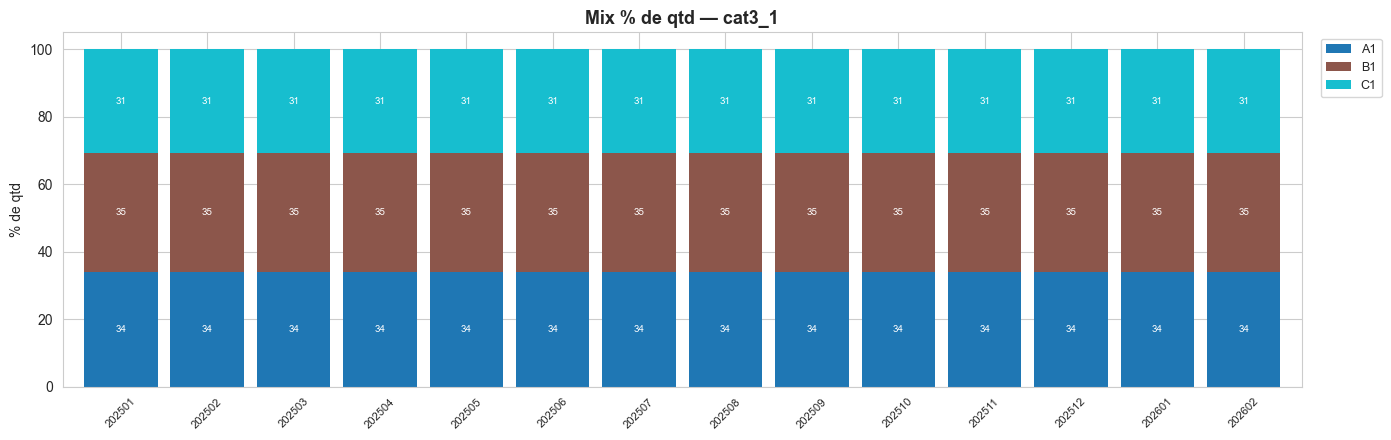

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat3_2,,,,,,,,,,,,,,
A2,30.7%,30.7%,30.7%,30.8%,30.8%,30.7%,30.7%,30.7%,30.8%,30.7%,30.7%,30.8%,30.8%,30.7%
B2,35.4%,35.4%,35.3%,35.3%,35.4%,35.4%,35.4%,35.4%,35.4%,35.4%,35.4%,35.4%,35.4%,35.4%
C2,33.9%,33.9%,33.9%,33.9%,33.9%,33.9%,33.9%,33.9%,33.9%,33.9%,33.9%,33.9%,33.9%,33.9%


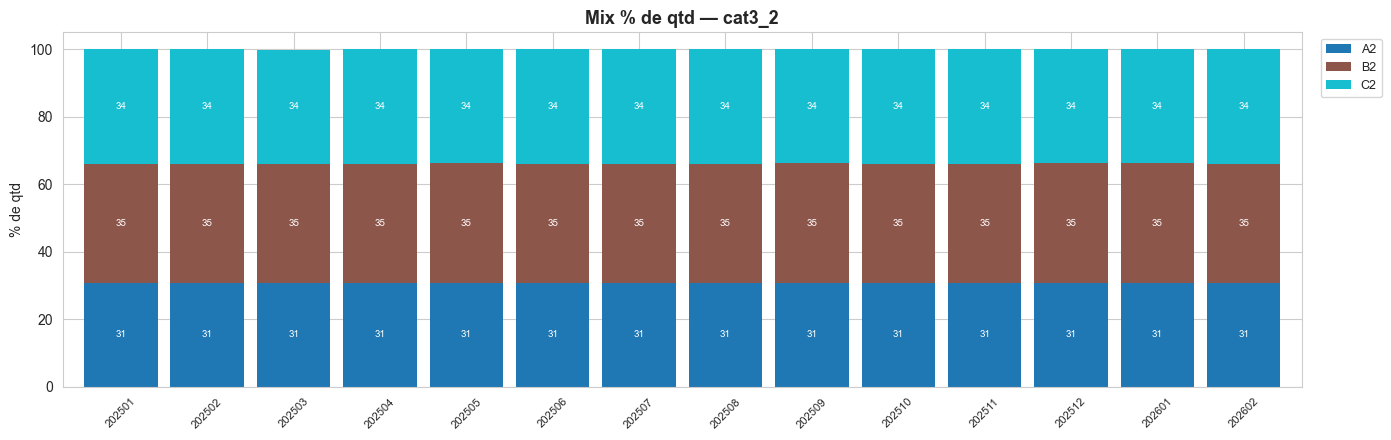

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat3_3,,,,,,,,,,,,,,
A3,36.1%,28.0%,29.4%,38.1%,35.6%,28.1%,33.0%,24.9%,32.4%,27.5%,28.2%,25.1%,32.9%,32.8%
B3,32.1%,30.5%,32.1%,30.3%,35.5%,33.6%,31.4%,40.8%,37.7%,42.1%,30.3%,37.7%,29.7%,33.0%
C3,31.9%,41.4%,38.4%,31.5%,28.9%,38.3%,35.6%,34.3%,29.9%,30.4%,41.4%,37.3%,37.4%,34.2%


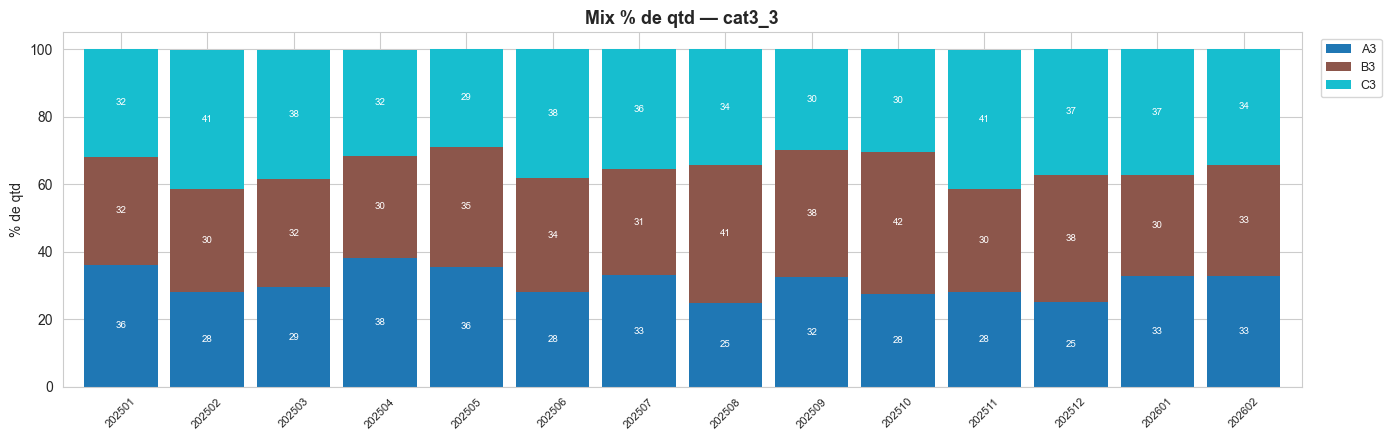

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat3_4,,,,,,,,,,,,,,
A4,32.9%,32.9%,32.9%,32.9%,32.9%,32.9%,32.9%,32.9%,32.9%,32.9%,32.9%,32.9%,32.9%,32.9%
B4,32.5%,32.5%,32.5%,32.5%,32.5%,32.5%,32.5%,32.5%,32.5%,32.5%,32.5%,32.5%,32.5%,32.5%
C4,34.6%,34.6%,34.6%,34.6%,34.6%,34.6%,34.6%,34.6%,34.6%,34.6%,34.6%,34.6%,34.6%,34.6%


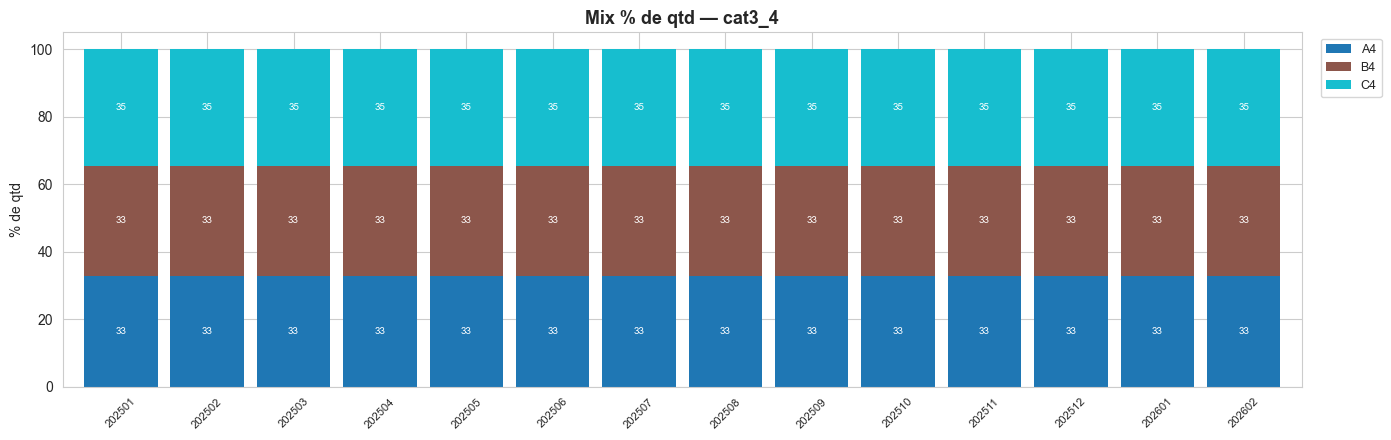

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat3_5,,,,,,,,,,,,,,
A5,33.4%,33.4%,33.4%,33.4%,33.4%,33.4%,33.4%,33.4%,33.4%,33.4%,33.4%,33.4%,33.4%,33.4%
B5,34.0%,34.0%,34.0%,34.0%,34.0%,34.0%,34.0%,34.0%,34.0%,34.0%,34.0%,34.0%,34.0%,34.0%
C5,32.6%,32.6%,32.6%,32.6%,32.6%,32.6%,32.6%,32.6%,32.6%,32.6%,32.6%,32.6%,32.6%,32.6%


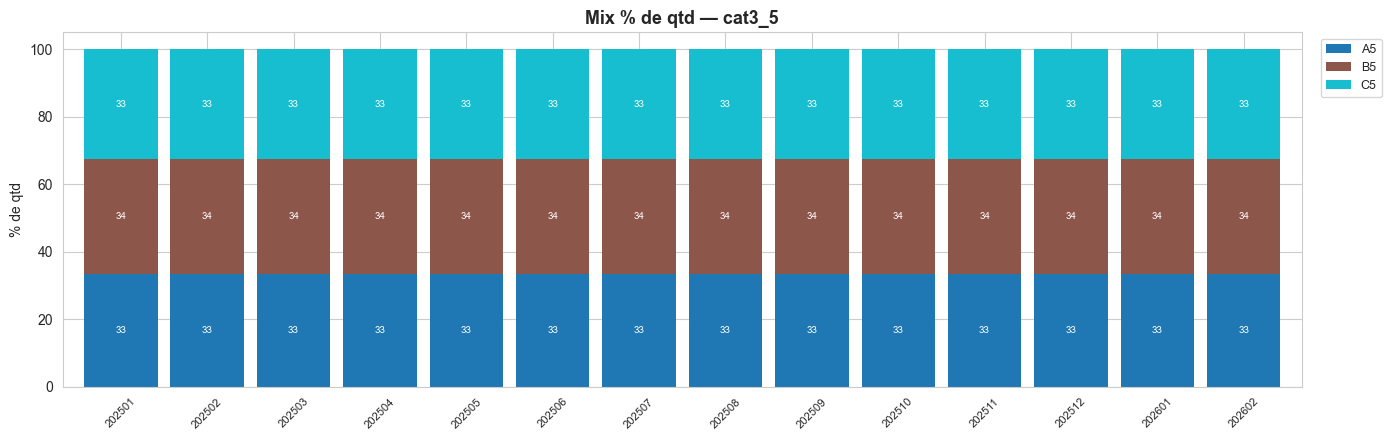

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat3_6,,,,,,,,,,,,,,
A6,40.9%,30.1%,33.7%,35.8%,27.1%,31.3%,37.8%,45.4%,34.3%,33.6%,34.1%,35.4%,31.5%,42.2%
B6,36.4%,34.8%,27.8%,35.6%,37.7%,37.2%,29.0%,26.9%,34.3%,32.4%,37.1%,35.2%,28.5%,28.0%
C6,22.7%,35.1%,38.5%,28.6%,35.2%,31.5%,33.2%,27.7%,31.3%,34.0%,28.7%,29.4%,40.1%,29.7%


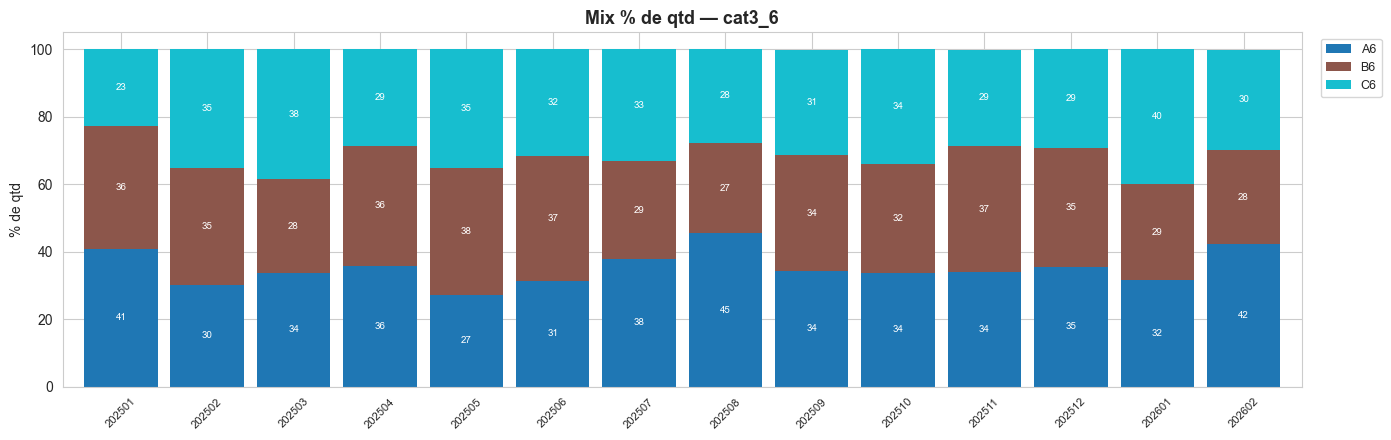

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat4_1,,,,,,,,,,,,,,
A1,23.0%,23.0%,23.0%,23.0%,23.0%,23.0%,23.0%,23.0%,23.0%,23.0%,23.0%,23.0%,23.0%,23.0%
B1,24.1%,24.1%,24.1%,24.1%,24.1%,24.1%,24.1%,24.1%,24.1%,24.1%,24.1%,24.1%,24.1%,24.1%
C1,26.3%,26.3%,26.3%,26.3%,26.3%,26.3%,26.3%,26.3%,26.3%,26.3%,26.3%,26.3%,26.3%,26.3%
D1,26.5%,26.5%,26.5%,26.5%,26.5%,26.5%,26.5%,26.5%,26.5%,26.5%,26.5%,26.5%,26.5%,26.5%


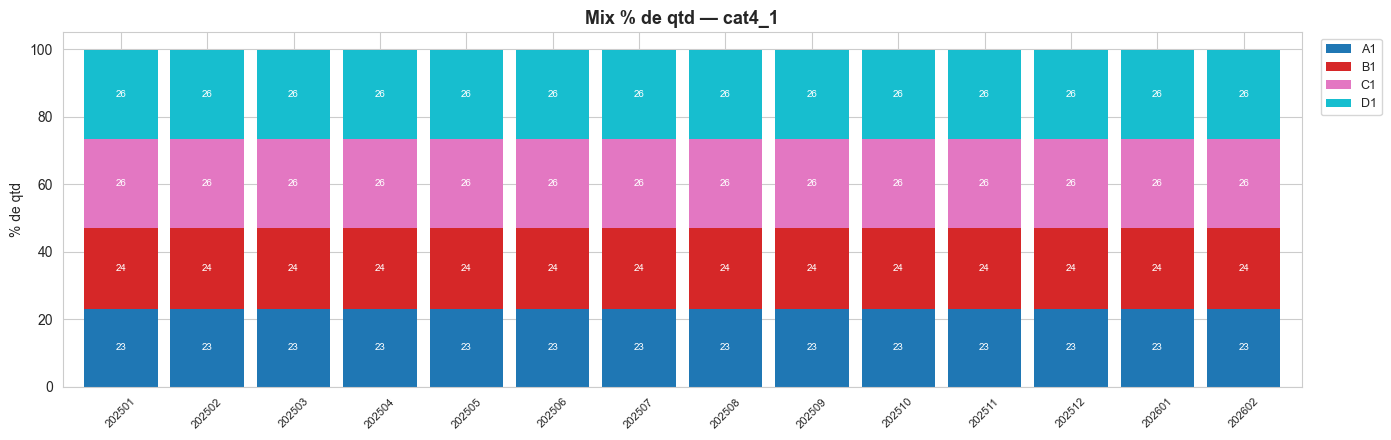

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat4_2,,,,,,,,,,,,,,
A2,31.1%,20.8%,23.6%,15.2%,26.0%,26.8%,28.0%,15.8%,23.9%,22.0%,28.5%,20.7%,31.4%,19.9%
B2,21.9%,25.0%,30.9%,32.3%,21.3%,26.0%,19.5%,33.6%,24.4%,16.6%,29.7%,29.7%,22.1%,17.6%
C2,20.0%,30.0%,23.4%,24.0%,30.7%,20.0%,34.9%,23.0%,25.2%,27.7%,14.6%,23.2%,22.7%,31.8%
D2,27.0%,24.3%,22.1%,28.6%,22.0%,27.2%,17.6%,27.6%,26.5%,33.7%,27.2%,26.4%,23.8%,30.6%


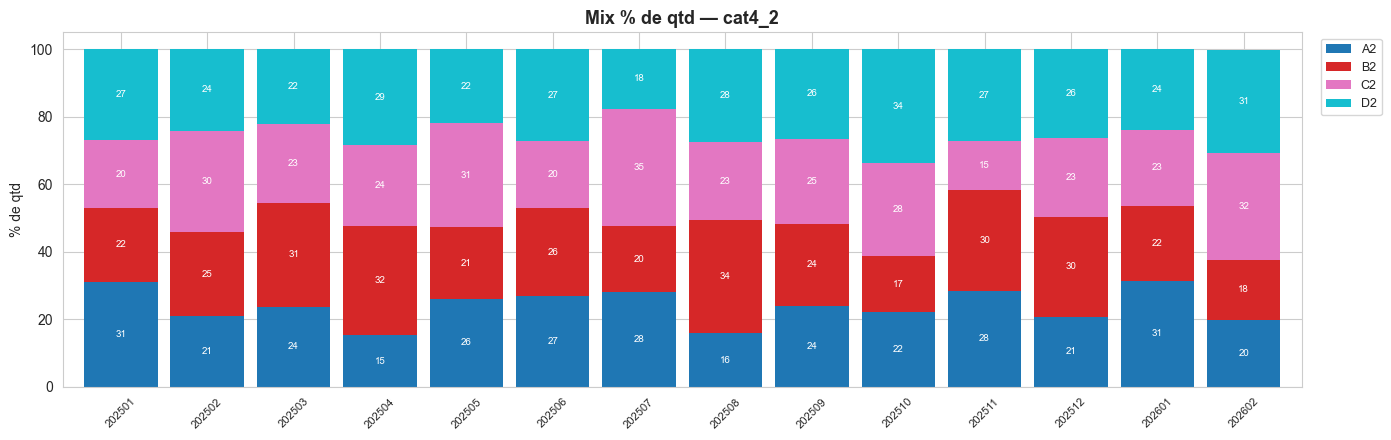

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat4_3,,,,,,,,,,,,,,
A3,25.3%,25.3%,25.3%,25.3%,25.3%,25.3%,25.3%,25.3%,25.3%,25.3%,25.3%,25.3%,25.3%,25.3%
B3,25.4%,25.4%,25.4%,25.4%,25.4%,25.4%,25.4%,25.4%,25.4%,25.4%,25.4%,25.4%,25.4%,25.4%
C3,24.4%,24.4%,24.4%,24.4%,24.4%,24.4%,24.4%,24.4%,24.4%,24.4%,24.4%,24.4%,24.4%,24.4%
D3,24.9%,24.9%,24.9%,24.9%,24.9%,24.9%,24.9%,24.9%,24.9%,24.9%,24.9%,24.9%,24.9%,24.9%


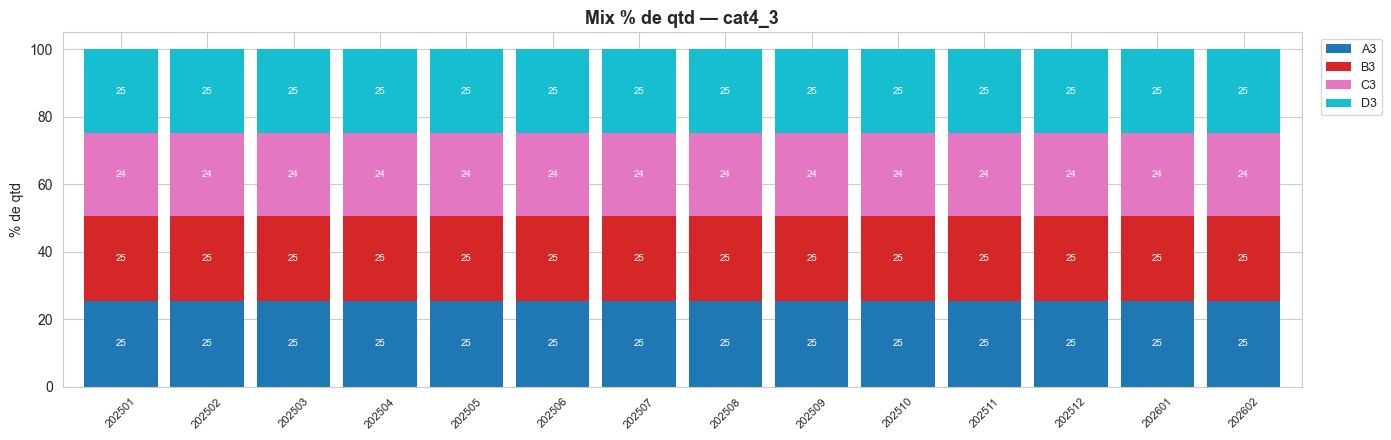

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat10_1,,,,,,,,,,,,,,
C1,6.0%,7.9%,6.6%,7.5%,15.5%,11.4%,9.3%,9.8%,14.4%,6.3%,10.7%,14.0%,14.2%,10.4%
C10,5.3%,6.3%,11.7%,9.6%,8.4%,9.4%,5.1%,6.5%,8.5%,8.7%,12.1%,8.3%,11.8%,11.5%
C2,14.4%,11.6%,15.6%,14.0%,14.8%,10.8%,9.7%,10.1%,10.7%,7.8%,8.4%,10.2%,15.9%,10.9%
C3,8.3%,13.0%,9.8%,12.6%,8.6%,6.7%,14.2%,12.9%,9.8%,12.4%,9.4%,8.8%,6.8%,9.2%
C4,12.6%,14.4%,12.7%,12.0%,14.0%,20.1%,9.7%,9.0%,6.5%,6.6%,9.2%,12.0%,13.1%,8.3%
C5,10.8%,12.5%,6.0%,6.7%,10.0%,10.1%,11.7%,10.9%,10.5%,12.9%,15.1%,6.5%,10.8%,10.9%
C6,9.5%,13.0%,9.3%,13.2%,11.2%,7.7%,10.1%,8.4%,9.0%,10.9%,7.0%,10.6%,7.7%,10.1%
C7,16.4%,5.3%,3.6%,8.8%,5.6%,7.9%,12.6%,16.3%,7.2%,11.8%,13.8%,11.2%,5.6%,9.2%
C8,3.0%,9.6%,7.8%,7.3%,7.9%,5.5%,4.7%,7.4%,9.7%,10.3%,5.9%,10.8%,6.0%,10.6%


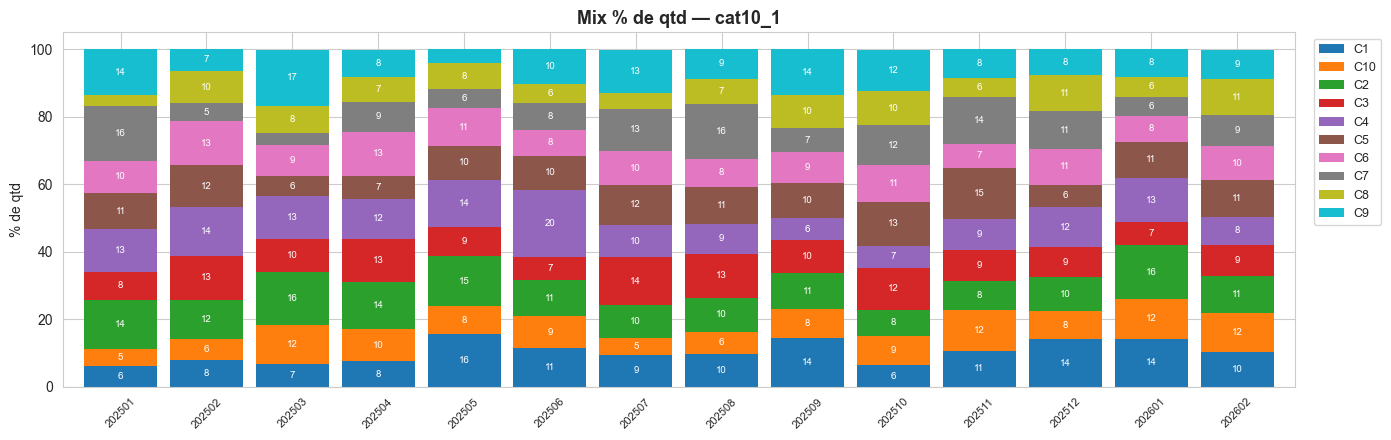

In [150]:
# Tabelas e gráficos de mix (% de qtd) — heatmap por coluna + barras empilhadas 100%
for col in cat_analise:
    pivot_mix = calcular_mix_pct(df, col)
    exibir_tabela_heatmap(pivot_mix, f'Mix % de qtd — {col}', eixo_cor=0)
    plotar_empilhado_100(pivot_mix, f'Mix % de qtd — {col}')

### Taxa de Ativação por Categoria (perc_indicador)

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat3_1,,,,,,,,,,,,,,
A1,82.6%,82.2%,80.1%,78.3%,86.9%,82.0%,81.8%,85.6%,68.4%,74.5%,61.7%,51.8%,53.6%,40.3%
B1,75.5%,77.0%,79.0%,77.3%,75.2%,74.8%,73.8%,77.2%,73.0%,67.0%,61.1%,55.1%,43.6%,40.8%
C1,68.9%,67.1%,66.6%,69.1%,65.3%,70.7%,70.2%,64.8%,66.3%,48.9%,47.6%,45.3%,32.7%,32.6%


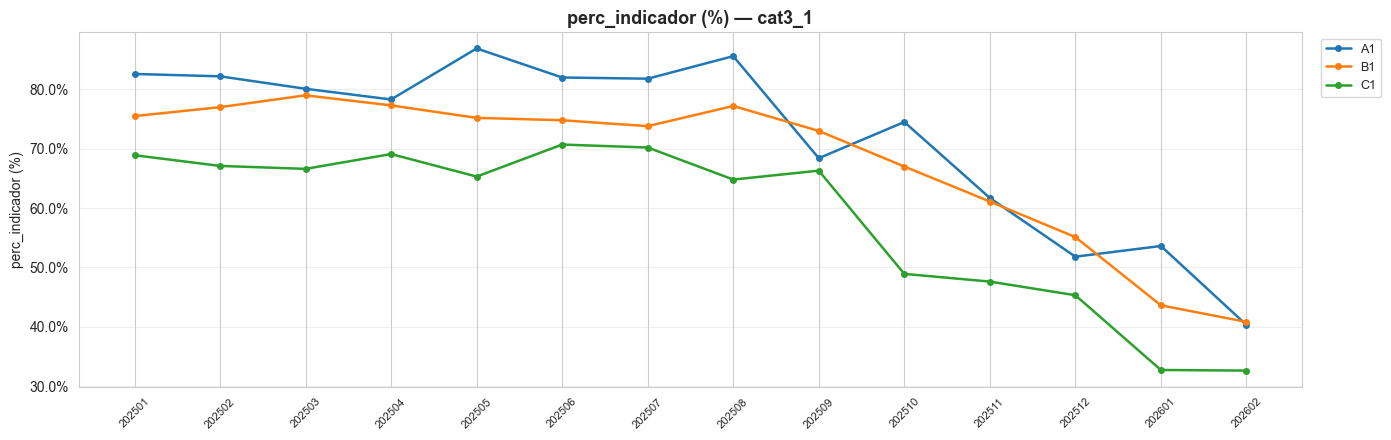

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat3_2,,,,,,,,,,,,,,
A2,61.0%,67.6%,64.5%,66.5%,67.6%,62.1%,64.7%,68.4%,55.7%,54.6%,52.9%,37.8%,28.1%,26.2%
B2,86.7%,81.0%,79.4%,80.0%,84.4%,83.9%,81.4%,81.5%,81.0%,70.0%,64.8%,60.6%,53.1%,50.4%
C2,78.2%,77.6%,81.6%,77.8%,75.2%,80.3%,78.9%,77.9%,69.7%,66.1%,53.1%,52.9%,47.9%,36.0%


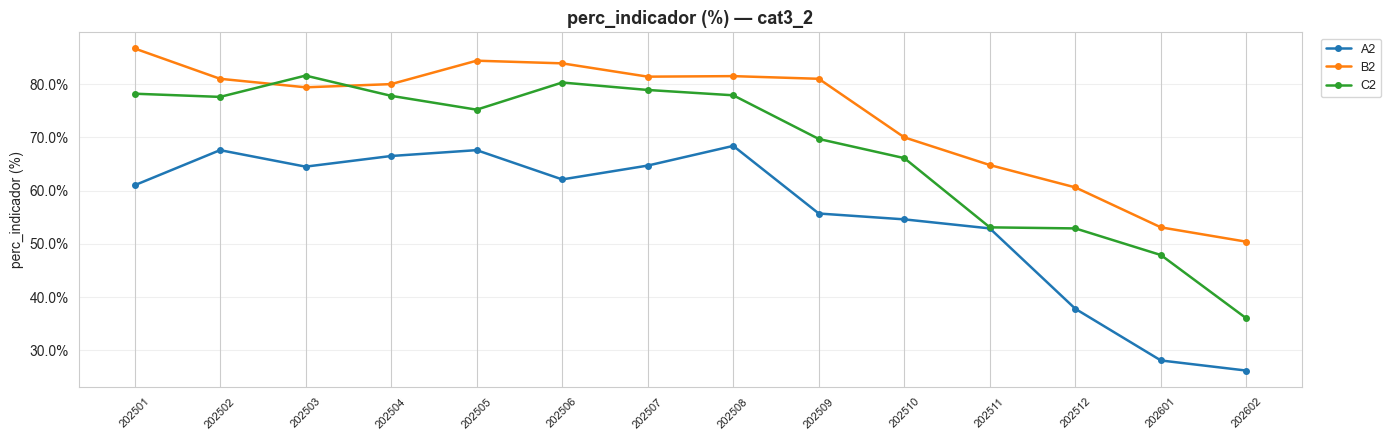

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat3_3,,,,,,,,,,,,,,
A3,78.8%,86.7%,84.7%,83.8%,84.4%,84.0%,84.6%,79.9%,73.3%,70.3%,70.2%,67.8%,49.4%,48.5%
B3,77.4%,75.9%,75.2%,75.7%,73.7%,80.0%,75.5%,76.3%,71.9%,64.2%,58.8%,47.7%,43.4%,31.3%
C3,71.1%,68.1%,68.9%,64.1%,68.9%,66.5%,66.8%,73.4%,61.8%,57.9%,47.1%,43.0%,38.8%,34.6%


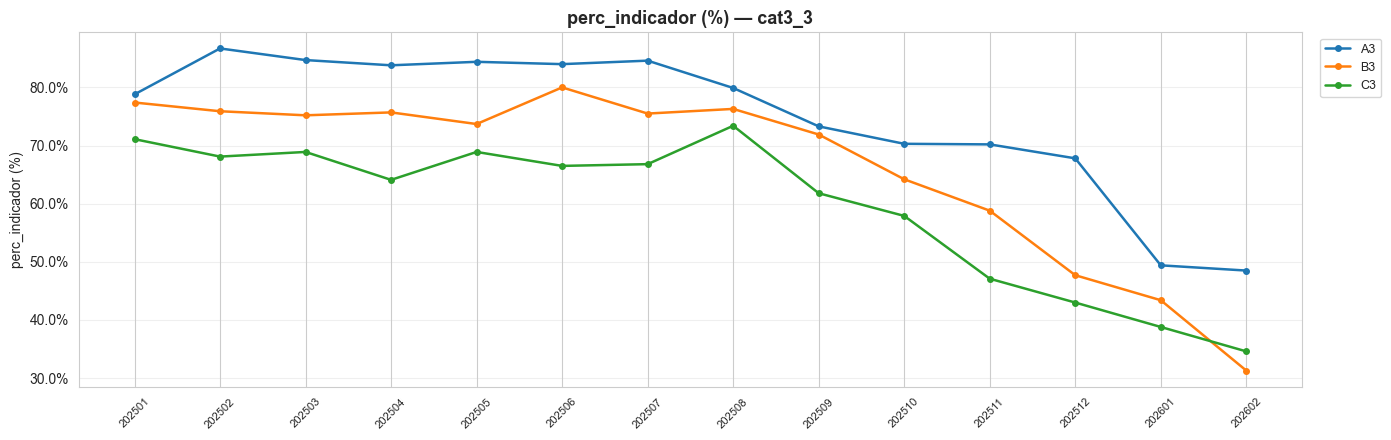

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat3_4,,,,,,,,,,,,,,
A4,64.8%,65.3%,71.5%,72.6%,67.9%,62.7%,71.7%,68.7%,63.8%,48.3%,53.0%,41.9%,37.3%,28.7%
B4,79.4%,78.8%,71.4%,73.5%,75.8%,79.2%,76.2%,81.2%,69.3%,68.9%,50.5%,50.0%,46.8%,40.9%
C4,83.2%,82.8%,83.3%,79.1%,84.1%,85.5%,78.2%,78.7%,74.7%,74.2%,67.3%,60.5%,46.7%,44.3%


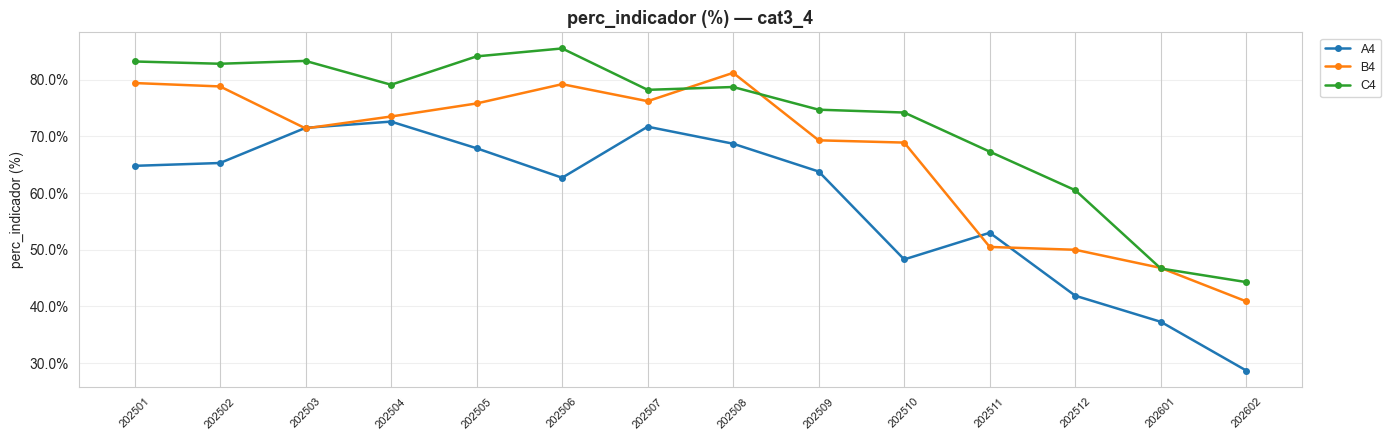

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat3_5,,,,,,,,,,,,,,
A5,82.1%,75.9%,73.8%,82.4%,76.1%,79.1%,80.3%,75.4%,72.0%,72.2%,68.4%,61.5%,48.6%,44.1%
B5,72.1%,78.9%,76.0%,75.2%,81.0%,76.5%,73.7%,77.2%,71.5%,61.2%,52.2%,47.0%,42.9%,32.6%
C5,73.5%,72.1%,76.9%,67.6%,71.0%,72.2%,72.2%,76.0%,64.4%,58.4%,50.8%,44.3%,39.3%,37.5%


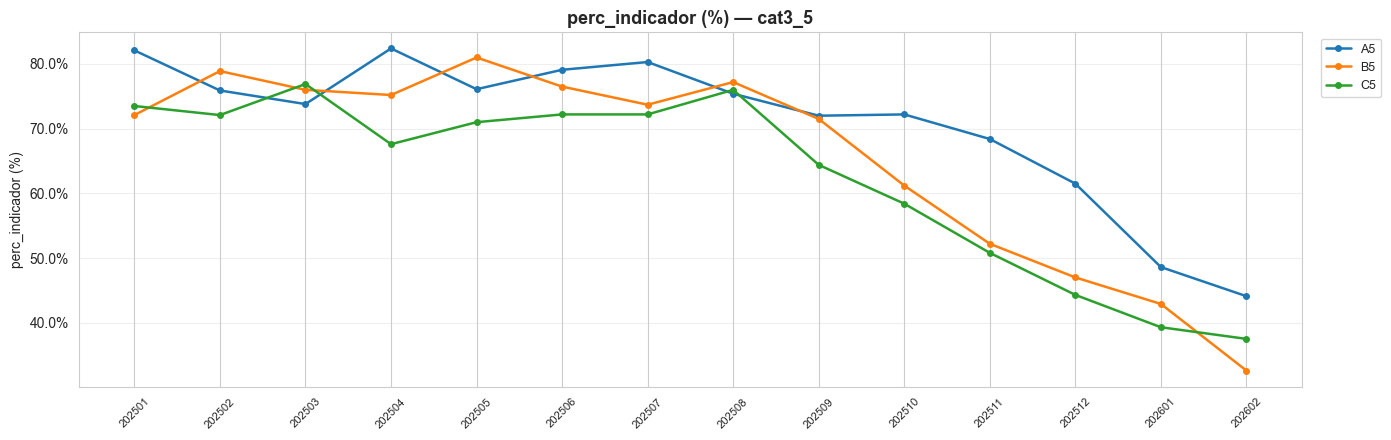

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat3_6,,,,,,,,,,,,,,
A6,69.7%,64.3%,68.3%,69.8%,66.6%,68.7%,69.1%,69.1%,62.0%,62.5%,48.4%,40.9%,34.8%,30.2%
B6,82.2%,82.9%,84.0%,77.8%,88.3%,76.9%,81.9%,84.5%,70.5%,64.0%,62.3%,51.0%,49.5%,48.0%
C6,77.0%,78.4%,75.8%,78.5%,70.4%,82.1%,77.0%,80.0%,76.2%,65.3%,61.0%,63.0%,46.5%,39.9%


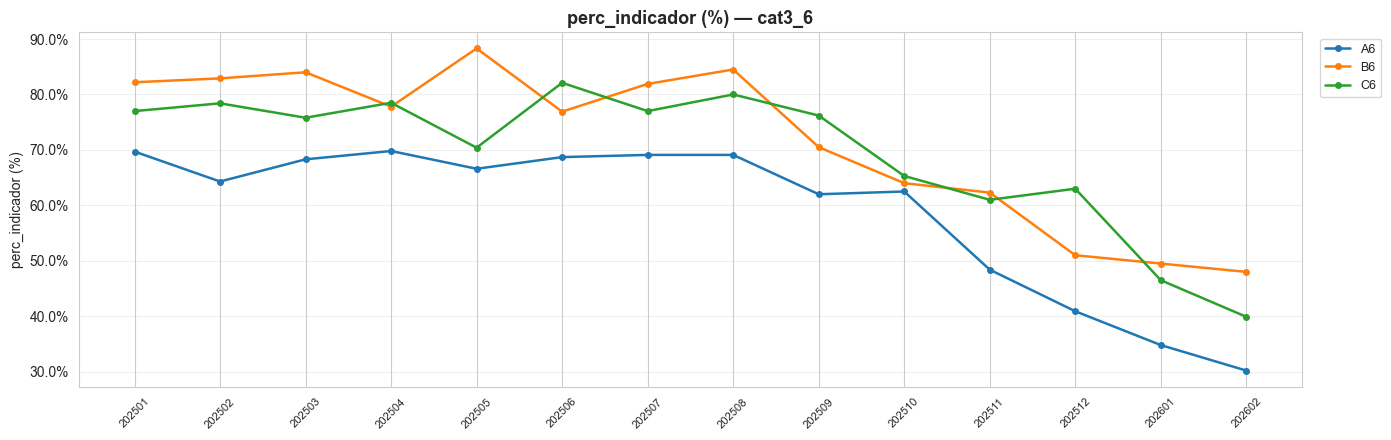

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat4_1,,,,,,,,,,,,,,
A1,88.2%,78.2%,81.8%,82.9%,87.4%,83.5%,86.8%,86.9%,83.4%,77.0%,60.2%,67.4%,54.7%,52.6%
B1,78.8%,79.3%,77.6%,77.3%,69.9%,81.3%,83.7%,77.5%,71.8%,67.1%,61.3%,47.3%,50.0%,45.5%
C1,72.7%,73.8%,76.9%,73.5%,79.7%,67.7%,63.9%,76.1%,64.7%,57.2%,57.5%,47.9%,41.7%,30.3%
D1,65.8%,72.3%,66.9%,68.0%,68.3%,72.8%,69.4%,66.0%,59.5%,56.5%,50.4%,43.0%,30.1%,26.4%


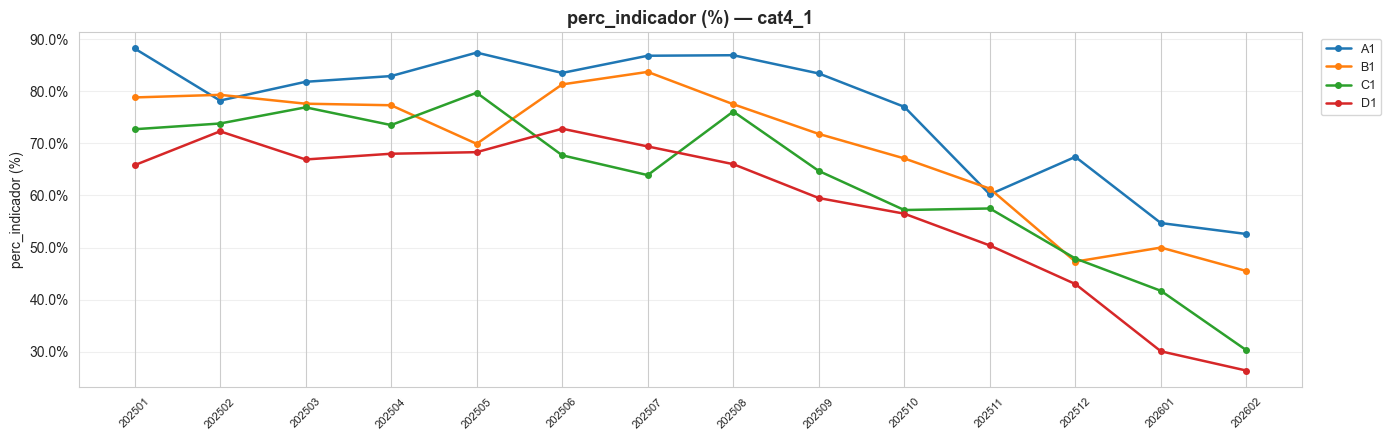

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat4_2,,,,,,,,,,,,,,
A2,63.6%,63.9%,65.7%,67.6%,62.9%,58.6%,68.6%,62.6%,59.5%,55.6%,53.3%,34.4%,37.7%,26.1%
B2,79.9%,77.8%,76.2%,72.5%,74.6%,78.7%,69.2%,72.3%,72.7%,61.3%,50.6%,45.9%,42.1%,36.4%
C2,77.1%,74.2%,78.9%,75.0%,83.0%,82.2%,79.7%,80.3%,65.8%,64.5%,57.1%,58.6%,48.1%,42.1%
D2,85.9%,85.5%,81.7%,82.2%,83.6%,85.8%,84.6%,85.5%,78.5%,70.2%,68.4%,63.0%,48.8%,42.7%


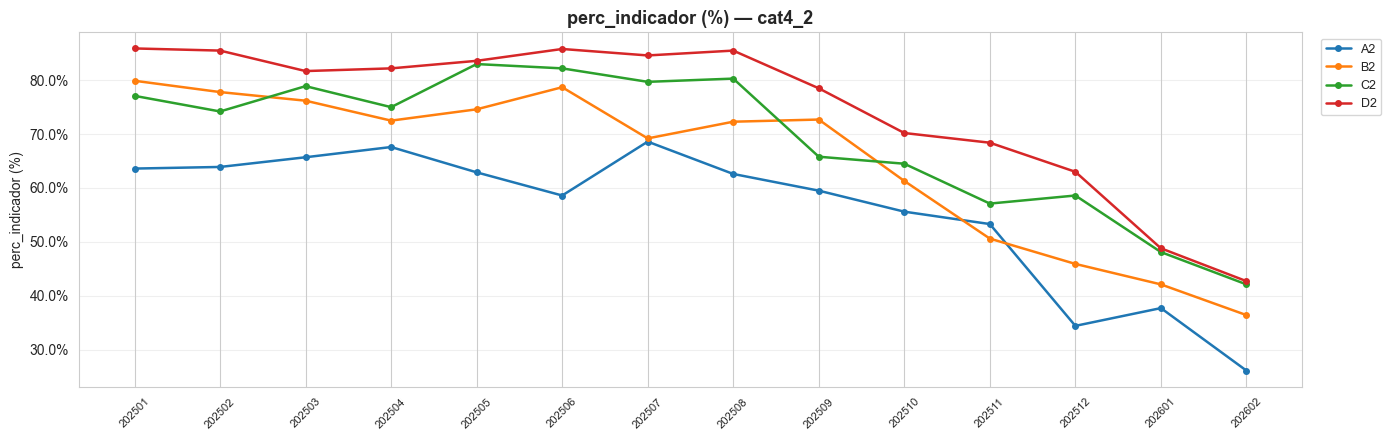

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat4_3,,,,,,,,,,,,,,
A3,79.6%,79.7%,80.5%,78.6%,85.9%,81.1%,85.3%,82.5%,75.8%,68.2%,71.7%,67.8%,60.1%,45.4%
B3,81.9%,79.5%,83.3%,79.4%,85.9%,86.1%,78.1%,81.0%,76.4%,66.6%,57.8%,54.2%,49.4%,36.9%
C3,67.4%,76.5%,69.5%,73.1%,70.0%,75.8%,72.0%,64.8%,62.0%,67.6%,48.3%,46.6%,32.1%,38.7%
D3,74.4%,67.1%,68.7%,69.2%,62.2%,60.5%,66.0%,76.2%,62.8%,53.4%,50.4%,34.8%,32.4%,31.2%


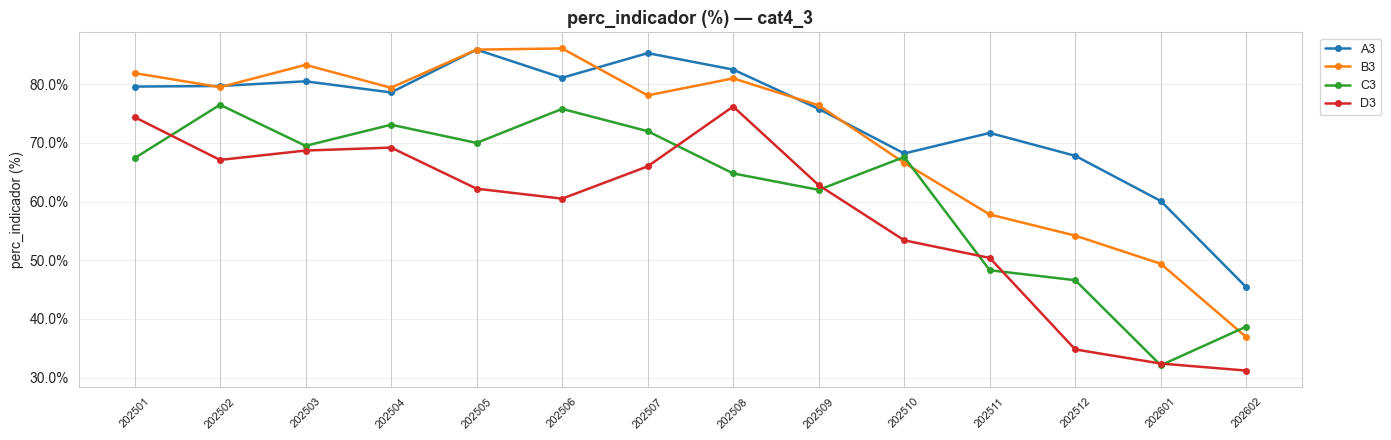

,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
cat10_1,,,,,,,,,,,,,,
C1,88.8%,88.9%,92.6%,80.0%,90.2%,94.8%,90.4%,85.3%,91.6%,87.3%,79.6%,76.5%,50.5%,60.7%
C10,57.2%,57.8%,52.5%,58.7%,50.7%,56.7%,54.5%,52.5%,51.5%,38.4%,29.9%,25.9%,18.5%,20.9%
C2,92.5%,70.6%,91.7%,83.4%,86.2%,89.6%,85.8%,87.0%,87.3%,89.2%,79.1%,65.1%,65.3%,47.2%
C3,80.0%,75.9%,84.0%,86.4%,90.6%,86.4%,84.1%,83.0%,80.9%,77.8%,69.8%,63.2%,45.7%,53.4%
C4,79.3%,74.3%,82.1%,82.3%,80.5%,81.4%,83.3%,76.8%,84.6%,62.6%,62.5%,65.9%,45.9%,40.9%
C5,84.4%,81.8%,87.9%,76.1%,77.0%,81.2%,82.6%,77.0%,70.4%,70.4%,64.5%,55.2%,39.3%,37.8%
C6,79.6%,79.7%,69.4%,78.8%,63.3%,67.3%,82.9%,82.8%,60.9%,61.1%,51.8%,42.2%,41.4%,39.5%
C7,66.6%,74.3%,80.4%,70.8%,70.6%,67.6%,63.0%,72.0%,60.8%,64.5%,45.6%,36.7%,34.9%,32.1%
C8,57.9%,80.3%,61.6%,58.1%,61.4%,67.8%,62.6%,67.9%,61.3%,49.6%,39.2%,32.1%,42.6%,27.2%


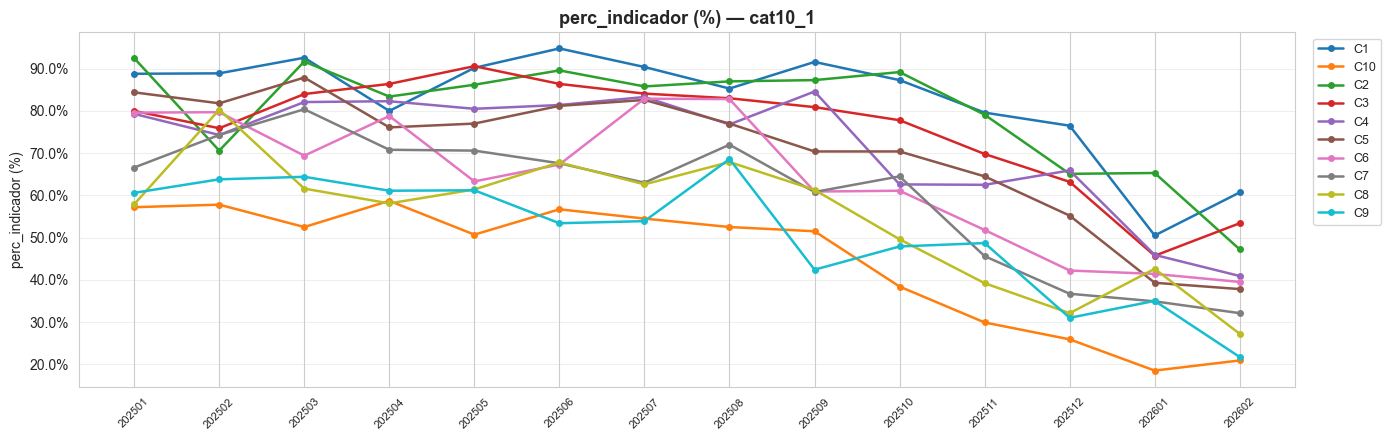

In [151]:
# Tabelas e gráficos de perc_indicador — heatmap ao longo dos meses (verde=alto, vermelho=baixo)
for col in cat_analise:
    pivot_atvc = calcular_perc_atvc(df, col)
    exibir_tabela_heatmap(pivot_atvc, f'perc_indicador (%) — {col}', eixo_cor=1)
    plotar_linhas(pivot_atvc, f'perc_indicador (%) — {col}', ylabel='perc_indicador (%)')

## Significância Estatística e Decomposição de Variação

In [152]:
from scipy.stats import norm


def teste_z_proporcoes(x1, n1, x2, n2):
    """Teste z bilateral para diferença de duas proporções."""
    p_pool = (x1 + x2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z = ((x1/n1) - (x2/n2)) / se if se > 0 else 0.0
    p_value = 2 * (1 - norm.cdf(abs(z)))
    return z, p_value


# Agregar por mês
mensal = (
    df.groupby('ano_mes', sort=True)
    .agg(qtd=('qtd', 'sum'), qtd_indicador=('qtd_indicador', 'sum'))
    .reset_index()
)

# Teste z entre meses consecutivos
testes = []
for i in range(1, len(mensal)):
    ant, atu = mensal.iloc[i-1], mensal.iloc[i]
    perc_ant = ant['qtd_indicador'] / ant['qtd'] * 100
    perc_atu = atu['qtd_indicador'] / atu['qtd'] * 100
    z, p = teste_z_proporcoes(
        atu['qtd_indicador'], atu['qtd'],
        ant['qtd_indicador'], ant['qtd']
    )
    testes.append({
        'mes_anterior': int(ant['ano_mes']),
        'mes_atual': int(atu['ano_mes']),
        'perc_ant (%)': round(perc_ant, 1),
        'perc_atu (%)': round(perc_atu, 1),
        'Δ (pp)': round(perc_atu - perc_ant, 1),
        'z': round(z, 2),
        'p_value': p,
        'sig_5%': 'Sim' if p < 0.05 else 'Não',
    })

df_testes = pd.DataFrame(testes)

# Exibição com destaque de significância
display(
    df_testes.style
    .format({'p_value': '{:.4f}'})
    .apply(lambda s: [
        'background-color: #d4edda' if v == 'Sim' else 'background-color: #f8d7da'
        for v in s
    ], subset=['sig_5%'])
    .set_caption('Teste Z de proporções — perc_indicador mês a mês')
)

,mes_anterior,mes_atual,perc_ant (%),perc_atu (%),Δ (pp),z,p_value,sig_5%
0,202501,202502,75.900000,75.700000,-0.200000,-0.660000,0.5096,Não
1,202502,202503,75.700000,75.600000,-0.200000,-0.560000,0.5764,Não
2,202503,202504,75.600000,75.100000,-0.400000,-1.580000,0.1147,Não
3,202504,202505,75.100000,76.100000,1.000000,3.630000,0.0003,Sim
4,202505,202506,76.100000,75.900000,-0.200000,-0.600000,0.5477,Não
5,202506,202507,75.900000,75.400000,-0.500000,-1.910000,0.0562,Não
6,202507,202508,75.400000,76.200000,0.800000,3.810000,0.0001,Sim
7,202508,202509,76.200000,69.400000,-6.900000,-47.190000,0.0000,Sim
8,202509,202510,69.400000,64.000000,-5.400000,-33.930000,0.0000,Sim
9,202510,202511,64.000000,57.200000,-6.800000,-40.370000,0.0000,Sim


### Decomposição da Queda no perc_indicador (Shift-Share)

- **efeito_mix**: mudança na **composição** do público (peso de cada categoria).
- **efeito_taxa**: mudança na **eficiência** dentro da categoria (`qtd_indicador` / `qtd`).

A célula seguinte define as funções; a próxima mostra um **resumo executivo**: tabela **univariada** (uma linha por variável) e tabela **multivariada enxuta** (poucas combinações por tamanho k). O ranking completo pode ser salvo em CSV sem exibir mil linhas.


In [153]:
from itertools import combinations

# Períodos de comparação (edite conforme necessário)
MES_BASE = 202507
MES_COMP = 202602

# Tolerância (pp): segmento "estático" se |Δmix| e |Δtaxa| forem ambos abaixo do limiar
EPS_MIX_PP = 0.05
EPS_TAXA_PP = 0.05

# None = testa todas as combinações 1..N; ou use um inteiro (ex.: 4) para limitar tamanho
MAX_TAMANHO_COMBO = None


def decompor_variacao(df, col_cat, mes_base, mes_comp):
    """Decomposição shift-share do perc_indicador entre dois períodos.
    col_cat: nome de uma coluna (str) ou lista de colunas (segmento cruzado)."""
    d = df[df['ano_mes'].isin([mes_base, mes_comp])].copy()
    if isinstance(col_cat, (list, tuple)):
        cols = list(col_cat)
        key = '__seg__'
        d[key] = d[cols].astype(str).agg(' | '.join, axis=1)
        col_cat = key
    agg = (
        d.groupby(['ano_mes', col_cat])
        .agg(qtd=('qtd', 'sum'), qtd_indicador=('qtd_indicador', 'sum'))
        .reset_index()
    )

    base = agg[agg['ano_mes'] == mes_base].set_index(col_cat)
    comp = agg[agg['ano_mes'] == mes_comp].set_index(col_cat)

    cats = base.index.union(comp.index).sort_values()
    base, comp = base.reindex(cats, fill_value=0), comp.reindex(cats, fill_value=0)

    mix_b = base['qtd'] / base['qtd'].sum()
    mix_c = comp['qtd'] / comp['qtd'].sum()
    taxa_b = np.where(base['qtd'] > 0, base['qtd_indicador'] / base['qtd'], 0)
    taxa_c = np.where(comp['qtd'] > 0, comp['qtd_indicador'] / comp['qtd'], 0)

    d_mix = mix_c - mix_b
    d_taxa = taxa_c - taxa_b
    avg_mix = (mix_b + mix_c) / 2
    avg_taxa = (taxa_b + taxa_c) / 2

    return pd.DataFrame({
        f'mix_{mes_base} (%)': (mix_b * 100).round(1),
        f'mix_{mes_comp} (%)': (mix_c * 100).round(1),
        'Δmix (pp)': (d_mix * 100).round(2),
        f'taxa_{mes_base} (%)': (taxa_b * 100).round(1),
        f'taxa_{mes_comp} (%)': (taxa_c * 100).round(1),
        'Δtaxa (pp)': (d_taxa * 100).round(2),
        'efeito_mix (pp)': (d_mix * avg_taxa * 100).round(2),
        'efeito_taxa (pp)': (avg_mix * d_taxa * 100).round(2),
        'efeito_total (pp)': ((d_mix * avg_taxa + avg_mix * d_taxa) * 100).round(2),
    }, index=cats).sort_values('efeito_total (pp)')


def segmento_estatico(res, eps_m=EPS_MIX_PP, eps_t=EPS_TAXA_PP):
    """True onde não houve mudança relevante de mix nem de taxa (não explica o delta nesse segmento)."""
    return (res['Δmix (pp)'].abs() < eps_m) & (res['Δtaxa (pp)'].abs() < eps_t)


def decompor_combinacao(df, cols_cat, mes_base, mes_comp, top_n=10):
    """Top impactos para uma combinação de colunas."""
    res = decompor_variacao(df, cols_cat, mes_base, mes_comp)
    return pd.concat([
        res.nsmallest(top_n, 'efeito_total (pp)'),
        res.nlargest(top_n, 'efeito_total (pp)')
    ]).drop_duplicates()


def varrer_todas_combinacoes(df, cat_list, mes_base, mes_comp,
                            eps_m=EPS_MIX_PP, eps_t=EPS_TAXA_PP, max_r=None):
    """Testa todas as combinações de 1..N variáveis; retorna métricas por combinação."""
    n = len(cat_list)
    max_r = min(max_r if max_r is not None else n, n)
    linhas = []
    for r in range(1, max_r + 1):
        for combo in combinations(cat_list, r):
            cols = list(combo)
            res = decompor_variacao(df, cols, mes_base, mes_comp)
            est = segmento_estatico(res, eps_m, eps_t)
            n_tot, n_est = len(res), int(est.sum())
            n_exp = n_tot - n_est
            soma_est = res.loc[est, 'efeito_total (pp)'].sum()
            soma_exp = res.loc[~est, 'efeito_total (pp)'].sum()
            delta_chk = res['efeito_total (pp)'].sum()
            pior = res.loc[~est, 'efeito_total (pp)'].min() if n_exp else np.nan
            linhas.append({
                'variáveis': ' × '.join(cols),
                'k': r,
                'n_segmentos': n_tot,
                'n_estáticos': n_est,
                'n_explicativos': n_exp,
                'soma_estáticos (pp)': round(soma_est, 2),
                'soma_explicativos (pp)': round(soma_exp, 2),
                'Δ verificação (pp)': round(delta_chk, 2),
                'pior_segmento (pp)': round(pior, 2) if pd.notna(pior) else np.nan,
            })
    return pd.DataFrame(linhas)


def apenas_segmentos_explicativos(res, eps_m=EPS_MIX_PP, eps_t=EPS_TAXA_PP):
    """Filtra só linhas onde mix ou taxa mudaram (onde está a explicação do delta)."""
    return res.loc[~segmento_estatico(res, eps_m, eps_t)]

# --- Resumo executivo (poucas linhas na tela) ---
K_MULTIV_MIN = 2
K_MULTIV_MAX = 5          # até qual k mostrar no resumo multivariado
TOP_COMBOS_POR_K = 2      # melhores combinações por valor de k


def resumo_univariado_executivo(df, cat_list, mes_base, mes_comp):
    """Uma linha por variável: pior categoria e se a decomposição marginal puxa mais mix ou taxa."""
    linhas = []
    for col in cat_list:
        res = decompor_variacao(df, col, mes_base, mes_comp)
        smix = res["efeito_mix (pp)"].sum()
        stax = res["efeito_taxa (pp)"].sum()
        pior_idx = res["efeito_total (pp)"].idxmin()
        pior = float(res["efeito_total (pp)"].min())
        if abs(smix) >= abs(stax):
            leitura = "História principal: mudança de mix (composição)"
        else:
            leitura = "História principal: mudança de eficiência (taxa interna)"
        if smix * stax < 0 and abs(smix) > 0.5 and abs(stax) > 0.5:
            leitura += " — mix e taxa em sentidos opostos"
        linhas.append(
            {
                "variável": col,
                "mix Σ (pp)": round(smix, 2),
                "taxa Σ (pp)": round(stax, 2),
                "pior categoria": str(pior_idx),
                "pior linha (pp)": round(pior, 2),
                "leitura": leitura,
            }
        )
    return pd.DataFrame(linhas).sort_values("pior linha (pp)")


def resumo_multivariado_enxuto(df, mes_base, mes_comp, df_rank, k_min, k_max, top_por_k):
    """Poucas linhas por k: combinações com queda mais concentrada no pior segmento."""
    linhas = []
    k_max = min(k_max, int(df_rank["k"].max()))
    for k in range(k_min, k_max + 1):
        sub = df_rank[df_rank["k"] == k]
        if sub.empty:
            continue
        sub = sub.sort_values("pior_segmento (pp)")
        for _, row in sub.head(top_por_k).iterrows():
            cols = row["variáveis"].split(" × ")
            res = decompor_variacao(df, cols, mes_base, mes_comp)
            pior_idx = res["efeito_total (pp)"].idxmin()
            ln = res.loc[pior_idx]
            em, et = float(ln["efeito_mix (pp)"]), float(ln["efeito_taxa (pp)"])
            if abs(em) >= abs(et):
                dica = "no pior segmento: pesa mais mix"
            else:
                dica = "no pior segmento: pesa mais taxa"
            linhas.append(
                {
                    "k": k,
                    "combinação": row["variáveis"],
                    "pior segmento": str(pior_idx),
                    "pior (pp)": round(float(row["pior_segmento (pp)"]), 2),
                    "mix seg. (pp)": round(em, 2),
                    "taxa seg. (pp)": round(et, 2),
                    "dica": dica,
                }
            )
    return pd.DataFrame(linhas)


In [154]:
# ── Delta global ──
agg_total = (
    df[df['ano_mes'].isin([MES_BASE, MES_COMP])]
    .groupby('ano_mes')
    .agg(qtd=('qtd', 'sum'), qtd_indicador=('qtd_indicador', 'sum'))
)
perc_b = agg_total.loc[MES_BASE, 'qtd_indicador'] / agg_total.loc[MES_BASE, 'qtd'] * 100
perc_c = agg_total.loc[MES_COMP, 'qtd_indicador'] / agg_total.loc[MES_COMP, 'qtd'] * 100
delta_pp = perc_c - perc_b

print(f'perc_indicador {MES_BASE}: {perc_b:.1f}%  →  {MES_COMP}: {perc_c:.1f}%  |  Δ = {delta_pp:+.1f} pp')
print('=' * 72)

# Avalia todas as combinações (usa cat_analise e MAX_TAMANHO_COMBO da célula anterior)
df_rank = varrer_todas_combinacoes(
    df, cat_analise, MES_BASE, MES_COMP, max_r=MAX_TAMANHO_COMBO
)

# Gravar ranking completo opcional (não exibe na tela)
SALVAR_RANKING_COMPLETO = None  # ex.: 'ranking_combinacoes.csv'
if SALVAR_RANKING_COMPLETO:
    df_rank.to_csv(SALVAR_RANKING_COMPLETO, index=False)

# ── 1) UNIVARIADO: todas as variáveis, uma linha cada ──
df_uni = resumo_univariado_executivo(df, cat_analise, MES_BASE, MES_COMP)
print('\n### UNIVARIADO — todas as variáveis em cat_analise')
display(
    df_uni.style
    .set_caption('Ordenado pela pior categoria. «leitura»: mix vs eficiência no agregado da variável.')
)

print('\n--- Conclusão rápida (univariado) ---')
r0 = df_uni.iloc[0]
print(
    f"• Maior queda concentrada numa categoria: **{r0['variável']}** → "
    f"{r0['pior categoria']} ({r0['pior linha (pp)']:.1f} pp). {r0['leitura']}"
)

# ── 2) MULTIVARIADO ENXUTO: poucas linhas por k ──
k_hi = min(K_MULTIV_MAX, len(cat_analise))
df_multi = resumo_multivariado_enxuto(
    df, MES_BASE, MES_COMP, df_rank,
    k_min=K_MULTIV_MIN, k_max=k_hi, top_por_k=TOP_COMBOS_POR_K,
)
print(
    f'\n### MULTIVARIADO — até {TOP_COMBOS_POR_K} combinações por k '
    f'(k = {K_MULTIV_MIN} … {k_hi})'
)
display(
    df_multi.style
    .set_caption('Cruzamentos com queda mais forte no pior segmento; «dica» = só nesse segmento.')
)

print(
    '\n*Ranking completo:*',
    len(df_rank),
    'linhas — não exibidas. Use SALVAR_RANKING_COMPLETO ou filtre df_rank no notebook.'
)


perc_indicador 202507: 75.4%  →  202602: 38.1%  |  Δ = -37.4 pp

### UNIVARIADO — todas as variáveis em cat_analise


,variável,mix Σ (pp),taxa Σ (pp),pior categoria,pior linha (pp),leitura
1,cat3_2,0.000000,-37.350000,C2,-14.560000,História principal: mudança de eficiência (taxa interna)
7,cat4_2,1.610000,-38.950000,C2,-14.430000,História principal: mudança de eficiência (taxa interna) — mix e taxa em sentidos opostos
0,cat3_1,0.000000,-37.360000,A1,-14.150000,História principal: mudança de eficiência (taxa interna)
3,cat3_4,0.000000,-37.350000,A4,-14.110000,História principal: mudança de eficiência (taxa interna)
4,cat3_5,0.000000,-37.350000,B5,-13.970000,História principal: mudança de eficiência (taxa interna)
5,cat3_6,-0.450000,-36.890000,C6,-13.740000,História principal: mudança de eficiência (taxa interna)
2,cat3_3,0.010000,-37.370000,B3,-13.390000,História principal: mudança de eficiência (taxa interna)
6,cat4_1,0.000000,-37.340000,D1,-11.380000,História principal: mudança de eficiência (taxa interna)
8,cat4_3,0.000000,-37.360000,B3,-10.460000,História principal: mudança de eficiência (taxa interna)
9,cat10_1,-1.200000,-36.160000,C3,-6.990000,História principal: mudança de eficiência (taxa interna)



--- Conclusão rápida (univariado) ---
• Maior queda concentrada numa categoria: **cat3_2** → C2 (-14.6 pp). História principal: mudança de eficiência (taxa interna)

### MULTIVARIADO — até 2 combinações por k (k = 2 … 5)


,k,combinação,pior segmento,pior (pp),mix seg. (pp),taxa seg. (pp),dica
0,2,cat3_4 × cat4_2,A4 | C2,-11.470000,-5.590000,-5.880000,no pior segmento: pesa mais taxa
1,2,cat3_3 × cat4_2,A3 | C2,-10.920000,-8.540000,-2.370000,no pior segmento: pesa mais mix
2,3,cat3_3 × cat3_4 × cat4_2,A3 | A4 | C2,-10.040000,-10.570000,0.530000,no pior segmento: pesa mais mix
3,3,cat3_3 × cat3_4 × cat3_6,A3 | A4 | C6,-9.140000,-6.140000,-3.000000,no pior segmento: pesa mais mix
4,4,cat3_3 × cat3_4 × cat3_6 × cat4_2,A3 | A4 | C6 | C2,-8.510000,-4.250000,-4.250000,no pior segmento: pesa mais mix
5,4,cat3_1 × cat3_4 × cat3_6 × cat4_2,A1 | A4 | C6 | C2,-6.440000,-3.790000,-2.650000,no pior segmento: pesa mais mix
6,5,cat3_1 × cat3_3 × cat3_4 × cat3_6 × cat4_2,A1 | A3 | A4 | C6 | C2,-6.480000,-3.240000,-3.240000,no pior segmento: pesa mais mix
7,5,cat3_1 × cat3_2 × cat3_3 × cat3_4 × cat4_1,A1 | C2 | A3 | A4 | B1,-4.940000,-2.470000,-2.470000,no pior segmento: pesa mais mix



*Ranking completo:* 1023 linhas — não exibidas. Use SALVAR_RANKING_COMPLETO ou filtre df_rank no notebook.


In [157]:
# Detalhe opcional: tabela completa só dos segmentos explicativos
EXPANDIR_TABELAS = True   # True para ver decomposição linha a linha
N_EXPANDIR = 10            # quantas linhas do resumo multivariado abrir

if EXPANDIR_TABELAS:
    fmt_pct = lambda r: {c: '{:.1f}%' for c in r.columns if c.startswith(('mix_', 'taxa_'))}
    fmt_pp = lambda r: {c: '{:+.2f}' for c in r.columns if '(pp)' in c}
    for _, row in df_multi.head(N_EXPANDIR).iterrows():
        cols = row['combinação'].split(' × ')
        res_full = decompor_variacao(df, cols, MES_BASE, MES_COMP)
        exp = apenas_segmentos_explicativos(res_full)
        print(f"\n--- {row['combinação']} (explicativos: {len(exp)}/{len(res_full)}) ---")
        display(
            exp.style
            .format({**fmt_pct(exp), **fmt_pp(exp)})
            .background_gradient(cmap='RdYlGn', subset=['efeito_total (pp)'], axis=0)
        )
else:
    print('Defina EXPANDIR_TABELAS = True acima para ver até N_EXPANDIR decomposições completas.')



--- cat3_4 × cat4_2 (explicativos: 12/12) ---


,mix_202507 (%),mix_202602 (%),Δmix (pp),taxa_202507 (%),taxa_202602 (%),Δtaxa (pp),efeito_mix (pp),efeito_taxa (pp),efeito_total (pp)
__seg__,,,,,,,,,
A4 | C2,17.8%,8.3%,-9.43,81.7%,36.7%,-45.00,-5.59,-5.88,-11.47
C4 | A2,11.6%,5.1%,-6.57,74.3%,33.4%,-40.85,-3.54,-3.40,-6.94
B4 | A2,10.2%,7.2%,-3.03,68.7%,29.4%,-39.31,-1.48,-3.41,-4.89
C4 | B2,7.0%,3.2%,-3.73,84.2%,40.5%,-43.72,-2.32,-2.24,-4.56
B4 | C2,9.1%,9.5%,+0.39,85.1%,38.2%,-46.86,+0.24,-4.35,-4.11
A4 | A2,6.2%,7.7%,+1.53,57.7%,18.4%,-39.30,+0.58,-2.74,-2.16
A4 | B2,7.0%,6.0%,-1.03,55.9%,29.5%,-26.42,-0.44,-1.71,-2.15
B4 | D2,7.7%,7.5%,-0.22,82.3%,56.6%,-25.67,-0.15,-1.95,-2.10
C4 | D2,8.0%,12.3%,+4.32,87.7%,45.7%,-41.99,+2.88,-4.27,-1.39



--- cat3_3 × cat4_2 (explicativos: 12/12) ---


,mix_202507 (%),mix_202602 (%),Δmix (pp),taxa_202507 (%),taxa_202602 (%),Δtaxa (pp),efeito_mix (pp),efeito_taxa (pp),efeito_total (pp)
__seg__,,,,,,,,,
A3 | C2,18.6%,7.2%,-11.37,84.3%,66.0%,-18.37,-8.54,-2.37,-10.92
B3 | A2,9.9%,6.7%,-3.21,77.6%,21.6%,-55.97,-1.59,-4.67,-6.26
C3 | A2,11.7%,7.4%,-4.31,54.9%,19.9%,-35.04,-1.61,-3.35,-4.96
C3 | B2,7.9%,2.0%,-5.85,60.8%,21.0%,-39.79,-2.39,-1.98,-4.37
B3 | B2,8.2%,5.9%,-2.31,71.3%,26.4%,-44.85,-1.13,-3.16,-4.29
B3 | C2,8.6%,9.9%,+1.27,72.4%,32.3%,-40.09,+0.66,-3.70,-3.04
A3 | A2,6.3%,5.8%,-0.54,79.6%,39.4%,-40.26,-0.32,-2.44,-2.77
C3 | D2,8.3%,10.0%,+1.70,79.9%,44.9%,-35.02,+1.06,-3.20,-2.14
C3 | C2,7.7%,14.7%,+7.03,76.9%,36.9%,-40.00,+4.00,-4.48,-0.48



--- cat3_3 × cat3_4 × cat4_2 (explicativos: 36/36) ---


...

,mix_202507 (%),mix_202602 (%),Δmix (pp),taxa_202507 (%),taxa_202602 (%),Δtaxa (pp),efeito_mix (pp),efeito_taxa (pp),efeito_total (pp)
__seg__,,,,,,,,,
A1 | A4 | C6 | C2,7.0%,0.2%,-6.81,92.1%,19.2%,-72.89,-3.79,-2.65,-6.44
B1 | C4 | A6 | A2,6.1%,0.1%,-6.07,62.8%,5.8%,-56.99,-2.08,-1.77,-3.85
C1 | A4 | A6 | C2,4.7%,0.4%,-4.34,77.2%,19.8%,-57.39,-2.11,-1.45,-3.56
B1 | C4 | C6 | B2,4.4%,0.0%,-4.33,79.8%,19.4%,-60.35,-2.15,-1.33,-3.48
B1 | C4 | B6 | D2,3.1%,0.0%,-3.12,91.6%,0.0%,-91.62,-1.43,-1.43,-2.86
A1 | B4 | A6 | A2,3.5%,0.4%,-3.14,62.5%,6.2%,-56.34,-1.08,-1.10,-2.18
C1 | A4 | C6 | C2,3.2%,0.0%,-3.15,66.3%,0.0%,-66.29,-1.05,-1.05,-2.09
B1 | B4 | A6 | C2,2.3%,0.4%,-1.90,84.1%,10.1%,-74.01,-0.90,-1.00,-1.89
A1 | C4 | B6 | A2,2.3%,0.6%,-1.75,96.2%,84.9%,-11.33,-1.59,-0.17,-1.75



--- cat3_1 × cat3_3 × cat3_4 × cat3_6 × cat4_2 (explicativos: 226/226) ---


,mix_202507 (%),mix_202602 (%),Δmix (pp),taxa_202507 (%),taxa_202602 (%),Δtaxa (pp),efeito_mix (pp),efeito_taxa (pp),efeito_total (pp)
__seg__,,,,,,,,,
A1 | A3 | A4 | C6 | C2,7.0%,0.0%,-7.04,92.1%,0.0%,-92.09,-3.24,-3.24,-6.48
B1 | B3 | C4 | C6 | B2,4.2%,0.0%,-4.17,80.9%,0.0%,-80.91,-1.69,-1.69,-3.38
C1 | A3 | A4 | A6 | C2,3.8%,0.0%,-3.80,74.6%,0.0%,-74.64,-1.42,-1.42,-2.83
B1 | B3 | C4 | A6 | A2,2.3%,0.0%,-2.33,92.0%,0.0%,-92.03,-1.07,-1.07,-2.14
C1 | A3 | A4 | C6 | C2,2.9%,0.0%,-2.94,68.8%,0.0%,-68.82,-1.01,-1.01,-2.02
C1 | B3 | B4 | B6 | C2,2.0%,0.0%,-2.01,89.7%,0.0%,-89.71,-0.90,-0.90,-1.81
B1 | C3 | C4 | A6 | A2,3.7%,0.1%,-3.64,44.8%,5.8%,-38.99,-0.92,-0.74,-1.66
A1 | C3 | B4 | A6 | A2,2.7%,0.0%,-2.71,57.5%,0.0%,-57.49,-0.78,-0.78,-1.56
B1 | B3 | C4 | B6 | D2,1.6%,0.0%,-1.55,97.5%,0.0%,-97.48,-0.76,-0.76,-1.51



--- cat3_1 × cat3_2 × cat3_3 × cat3_4 × cat4_1 (explicativos: 231/231) ---


,mix_202507 (%),mix_202602 (%),Δmix (pp),taxa_202507 (%),taxa_202602 (%),Δtaxa (pp),efeito_mix (pp),efeito_taxa (pp),efeito_total (pp)
__seg__,,,,,,,,,
A1 | C2 | A3 | A4 | B1,5.3%,0.0%,-5.30,93.2%,0.0%,-93.18,-2.47,-2.47,-4.94
A1 | B2 | A3 | A4 | D1,2.8%,0.0%,-2.78,87.3%,0.0%,-87.29,-1.21,-1.21,-2.43
C1 | B2 | A3 | A4 | D1,3.0%,0.1%,-2.91,69.7%,41.4%,-28.33,-1.61,-0.44,-2.05
A1 | C2 | C3 | B4 | C1,2.3%,0.0%,-2.28,81.6%,0.0%,-81.63,-0.93,-0.93,-1.86
C1 | A2 | A3 | A4 | C1,2.8%,0.4%,-2.49,67.5%,15.5%,-51.93,-1.03,-0.83,-1.86
B1 | C2 | B3 | C4 | A1,1.9%,0.0%,-1.91,94.2%,0.0%,-94.16,-0.90,-0.90,-1.80
B1 | C2 | B3 | C4 | D1,1.8%,0.2%,-1.62,97.3%,20.3%,-76.99,-0.95,-0.75,-1.70
A1 | B2 | C3 | B4 | C1,2.5%,0.0%,-2.54,62.1%,0.0%,-62.11,-0.79,-0.79,-1.58
B1 | C2 | C3 | C4 | D1,1.8%,0.2%,-1.63,85.1%,54.0%,-31.15,-1.13,-0.30,-1.44
